# TV under-reach, under-frequency: a sharper `ec_m` prior case study

**Objective.** The companion notebook (`meridian_ec_prior_case_study.ipynb`)
showed that a reach-based `ec_m` prior recovers the true half-saturation
point better than Meridian's default. Both notebooks derive that ground
truth the same way -- `simulate_adstock_hill_params()`'s "half of the
target audience reached at the channel's mean frequency" assumption (see
`data_simulator.py`) -- and that 50%-of-audience threshold is a **stylized
modeling choice** for generating a known, self-consistent ground truth, not
a claim that real-world half-saturation actually sits at 50% reach for any
real channel. This notebook doesn't change that definition. What it changes
is the *scenario*:

> Take a channel (TV) with a **large target audience**, but currently
> reached at **both low reach and low frequency** -- two independent forms
> of under-delivery, chosen so current execution sits far below that same
> 50%-of-audience threshold. Because Meridian's default `ec_m` prior
> (`TruncatedNormal(0.8, 0.8, [0.1, 10])`, see
> `meridian/model/prior_distribution.py`) assumes current execution is
> already close to half-saturation, it will systematically conclude this
> channel is far more saturated than the ground truth says it is -- and
> that mistaken conclusion carries directly into how much budget an
> optimizer recommends for it.

This stays entirely within the plain-impressions modeling approach (no
reach/frequency channel type), since that's what most measurement vendors
use in practice. As in the companion notebook, "true `ec_m`" throughout
means "true under this simulation's stated 50%-of-audience assumption" --
the point being demonstrated is the size of the gap between current
execution and *whatever* the DGP's threshold is, and that a reach-informed
prior recovers that gap regardless of whether 50% itself is realistic --
not that 50% has been independently validated as the real half-saturation
point for TV.

**How to read this notebook:**
- Section 1 builds a TV scenario with a large audience, low reach (~10%),
  and low frequency (1-2/week), and shows the resulting true `ec_m`.
- Section 2 fits `default` vs. `ec_only` (reach-informed) priors and
  reports a single headline diagnostic: the fraction of ceiling effect each
  model believes TV is capturing at its current delivery level, vs. the
  truth.
- Section 3 overlays the true, default-posterior, and informed-posterior
  Hill response curves.
- Section 4 compares marginal response at current execution.
- Section 5 compares budget-reallocation recommendations (via Meridian's
  `BudgetOptimizer`) against the true DGP-optimal allocation.
- Section 6 checks robustness: does the reach-informed prior still help
  when the audience/reach assumption behind it is only approximately, not
  exactly, right?

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize

from meridian.analysis import optimizer
from meridian.model import adstock_hill
from meridian.model import model
from meridian.analysis import visualizer

from data_simulator import SimulationConfig
from model_utils import build_model_spec
from model_utils import build_simulated_input
from model_utils import ceiling_fraction_at_median
from model_utils import filter_param_summary
from model_utils import hill_value
from model_utils import posterior_param_mean
from model_utils import PRIOR_VARIANTS

## 1. A large-audience, under-reached, under-frequency TV scenario

TV gets a large `target_audience_pop_frac`, a low `current_reach_frac`
(~10%), and a `frequency_range` capped at 1-2/week -- distinctly lower than
Display/Social's. `ec_m`'s ground-truth definition is unchanged from the
companion notebook (still "half of `target_audience_pop_frac` reached at
the channel's mean frequency" -- see `simulate_adstock_hill_params()`);
what's different here is that both under-delivery mechanisms push TV's
*current execution* far below that same threshold, so the resulting `ec_m`
(in units of "multiples of TV's own current median delivery") ends up far
above 1.

I0000 00:00:1785095249.398808 6772894 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


ec_m = [12.227814    1.8115484   0.49773476]


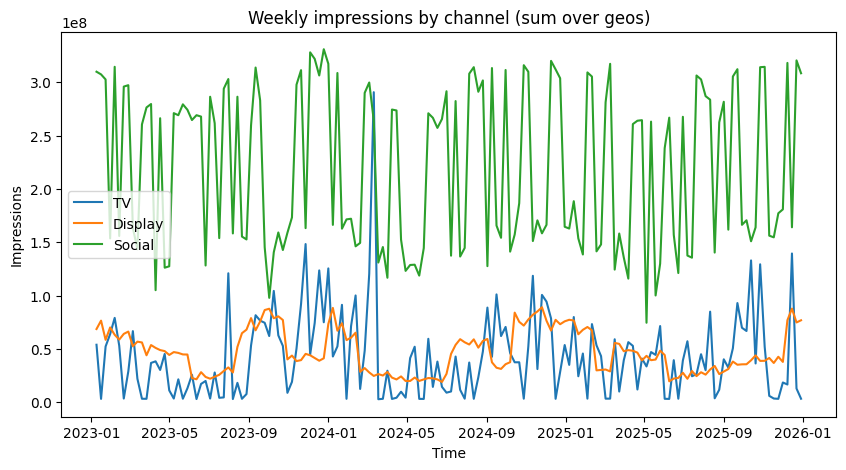

In [3]:
# TV: large target audience, but reached at low frequency (1-2/week) and
# only ~10% of that audience currently -- two independent forms of
# under-delivery. Display/Social keep a wider, higher-reach profile, so TV
# is the only channel deliberately built to sit far from its saturation
# point.
BASE_CONFIG_OVERRIDES = {
    'target_audience_pop_frac': {'TV': 0.60, 'Display': 0.10, 'Social': 0.15},
    'current_reach_frac': {'TV': 0.10, 'Display': 0.5, 'Social': 0.9},
    'frequency_range': {
        'TV': (1.0, 2.0),
        'Display': (1.0, 6.0),
        'Social': (5.0, 8.0),
    },
    'flight_style': {'TV': 'flighting', 'Display': 'flighting', 'Social': 'flighting'},
    'target_roi': {'TV': 3.0, 'Display': 1.0, 'Social': 2.0},

    # 'flight_burst_weeks': {'TV': 8, 'Display': 12, 'Social': 2},
    # 'flight_dark_weeks': {'TV': 8, 'Display': 12, 'Social': 2},
    # 'flight_floor': {'TV': 0.2, 'Display': 0.5, 'Social': 0.5},
    # 'seasonal_amplitude': {'TV': 0.6, 'Display': 0.3, 'Social': 0.1},
    # 'geo_audience_heterogeneity_sd': 0.25,
    # 'target_roi': {'TV': 3.5, 'Display': 2.0, 'Social': 1.5},
}

config = SimulationConfig.from_dict(BASE_CONFIG_OVERRIDES)
sim, data, ground_truth = build_simulated_input(config)
sim.plot_media_time_series()
plt.show()

In [4]:
audience_national_m = sim.audience_national_m.numpy()
mean_reach_frac_m = sim.reach_count_gtm.numpy().mean(axis=(0, 1)) / (
    sim.audience_g_m.numpy().mean(axis=0)
)
mean_frequency_m = sim.frequency_gtm.numpy().mean(axis=(0, 1))
true_ec_m = sim.ec_m.numpy()
true_ceiling_frac = ceiling_fraction_at_median(true_ec_m)

for i, ch in enumerate(config.channel_names):
  print(
      f'{ch}: target audience ≈ {audience_national_m[i] / 1e6:.1f}M, '
      f'reaching ≈ {mean_reach_frac_m[i] * 100:.1f}% at frequency '
      f'≈ {mean_frequency_m[i]:.1f}/week'
  )
print()
print(f'true ec_m (multiples of current median delivery): {true_ec_m}')
print(f'true fraction of ceiling effect captured today:   {true_ceiling_frac}')
print(f'true roi_m: {ground_truth["roi_m"]}')

TV: target audience ≈ 209.2M, reaching ≈ 13.6% at frequency ≈ 1.5/week
Display: target audience ≈ 35.4M, reaching ≈ 38.2% at frequency ≈ 3.5/week
Social: target audience ≈ 51.1M, reaching ≈ 66.1% at frequency ≈ 6.5/week

true ec_m (multiples of current median delivery): [12.227814    1.8115484   0.49773476]
true fraction of ceiling effect captured today:   [0.07559828 0.3556759  0.66767496]
true roi_m: [2.9999998 0.9999998 2.       ]


## 2. Headline diagnostic: fraction of ceiling effect captured today

Fit `default`, `ec_only` (reach-informed `ec_m`), and `ec_alpha_only`
(reach-informed `ec_m` *and* an adstock-decay-informed `alpha_m`) priors on
the same dataset. `ec_only` leaves `alpha_m` at Meridian's default
`Uniform(0, 1)` prior, same as `default` -- so any `alpha_m` recovery gap
under `ec_only` isn't fixed by informing `ec_m` alone. `ec_alpha_only`
additionally centers `alpha_m` on `sim.alpha_m`, the simulator's true
adstock retention rate, to test whether jointly informing both "shape"
parameters closes that gap (and any knock-on effect on `roi_m`). Then
compute, for the true `ec_m` and for each fitted model's posterior-mean
`ec_m`, `Hill(x=1)` -- the fraction of ceiling effect achieved at exactly
the channel's own current median delivery. This is the single number that
explains the business harm: a model that believes a channel has already
captured most of its ceiling effect will show flat marginal returns and
recommend against spending more on it.

In [5]:
MAIN_VARIANTS = ['default', 'ec_only', 'ec_alpha_only', 'ec_alpha_social_tight']
MCMC_KWARGS_SECTION2 = dict(n_chains=2, n_adapt=500, n_burnin=500, n_keep=1000, seed=1)

fitted_mmms = {}
summaries = {}
for variant in MAIN_VARIANTS:
  model_spec = build_model_spec(variant, sim, config)
  mmm = model.Meridian(input_data=data, model_spec=model_spec)
  mmm.sample_prior(500)
  mmm.sample_posterior(**MCMC_KWARGS_SECTION2)
  fitted_mmms[variant] = mmm
  summaries[variant] = az.summary(
      mmm.inference_data, extend=True, hdi_prob=0.9
  ).reset_index()

  print(f'--- {variant} ---')
  display(filter_param_summary(summaries[variant], 'alpha_m'))
  display(filter_param_summary(summaries[variant], 'ec_m'))
  display(filter_param_summary(summaries[variant], 'roi_m'))

2026-07-26 14:48:28.833734: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


--- default ---


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,index,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,alpha_m[TV],0.060,0.052,0.000,0.126,0.004,0.003,349.0,139.0,1.0
1,alpha_m[Display],0.323,0.250,0.001,0.701,0.006,0.005,2598.0,1154.0,1.0
2,alpha_m[Social],0.272,0.116,0.068,0.453,0.005,0.003,716.0,273.0,1.0


,index,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
159,ec_m[TV],1.501,0.460,0.786,2.263,0.021,0.015,379.0,151.0,1.00
160,ec_m[Display],0.764,0.554,0.100,1.568,0.012,0.009,1263.0,679.0,1.00
161,ec_m[Social],1.615,0.663,0.570,2.800,0.049,0.035,160.0,51.0,1.01


...

--- ec_alpha_social_tight ---


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,index,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,alpha_m[TV],0.311,0.026,0.271,0.357,0.001,0.0,1780.0,1209.0,1.0
1,alpha_m[Display],0.050,0.026,0.008,0.089,0.001,0.0,2036.0,908.0,1.0
2,alpha_m[Social],0.369,0.029,0.319,0.413,0.001,0.0,3317.0,1507.0,1.0


,index,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
159,ec_m[TV],12.537,1.291,10.463,14.559,0.025,0.018,2634.0,1458.0,1.00
160,ec_m[Display],1.806,0.186,1.501,2.100,0.004,0.003,2988.0,1168.0,1.01
161,ec_m[Social],0.509,0.050,0.429,0.595,0.001,0.001,2174.0,1579.0,1.00


,index,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
485,roi_m[TV],3.091,0.183,2.791,3.401,0.004,0.003,1674.0,1401.0,1.0
486,roi_m[Display],0.691,0.436,0.071,1.285,0.012,0.009,1719.0,1284.0,1.0
487,roi_m[Social],1.157,0.390,0.540,1.804,0.021,0.015,367.0,488.0,1.0


In [6]:
for variant in MAIN_VARIANTS:
  print(f'--- {variant} ---')
  mmm = fitted_mmms[variant]
  media_effect_summary = visualizer.MediaSummary(mmm).summary_table()
  display(media_effect_summary)
  display(filter_param_summary(summaries[variant], 'alpha_m'))
  display(filter_param_summary(summaries[variant], 'ec_m'))
  display(filter_param_summary(summaries[variant], 'roi_m'))
  media_effects = visualizer.MediaEffects(mmm)
  display(media_effects.plot_response_curves())
  display(media_effects.plot_hill_curves()['media'])

  budget_optimizer = optimizer.BudgetOptimizer(mmm)
  optimization_results = budget_optimizer.optimize()
  display(optimization_results.plot_spend_delta())
  display(optimization_results.plot_incremental_outcome_delta())
  display(optimization_results.plot_response_curves())

--- default ---


/Users/mariappan.subramanian/Documents/repo/meridian/build/__editable__.google_meridian-1.7.0-py3-none-any/meridian/analysis/visualizer.py:1728: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .aggregate(lambda g: f'{g[0]} ({g[1]}, {g[2]})')


,channel,distribution,impressions,% impressions,spend,% spend,cpm,incremental outcome,% contribution,roi,effectiveness,mroi,cpik
0,TV,prior,"6,683,297,792",12%,"$68,603,600",23%,$10,"$126,586,448 ($15,859,363, $374,020,320)","2.4% (0.3%, 7.1%)","1.8 (0.2, 5.5)","0.02 (0.00, 0.06)","0.8 (0.1, 2.5)","$0.0 ($0.0, $0.2)"
1,TV,posterior,"6,683,297,792",12%,"$68,603,600",23%,$10,"$528,310,432 ($359,698,688, $748,679,488)","10.9% (7.4%, 15.5%)","7.7 (5.2, 10.9)","0.08 (0.05, 0.11)","2.1 (1.8, 2.4)","$0.0 ($0.0, $0.0)"
2,Display,prior,"9,616,436,224",17%,"$20,087,192",7%,$2,"$36,361,844 ($5,799,901, $98,387,608)","0.7% (0.1%, 1.9%)","1.8 (0.3, 4.9)","0.00 (0.00, 0.01)","0.8 (0.1, 2.3)","$0.0 ($0.0, $0.1)"
3,Display,posterior,"9,616,436,224",17%,"$20,087,192",7%,$2,"$165,184,928 ($136,111,344, $194,948,208)","3.4% (2.8%, 4.0%)","8.2 (6.8, 9.7)","0.02 (0.01, 0.02)","5.7 (4.7, 6.7)","$0.0 ($0.0, $0.0)"
4,Social,prior,"41,382,760,448",72%,"$208,530,976",70%,$5,"$370,116,672 ($62,277,516, $1,120,641,024)","7.0% (1.2%, 21.1%)","1.8 (0.3, 5.4)","0.01 (0.00, 0.03)","0.8 (0.1, 2.6)","$0.0 ($0.0, $0.1)"
5,Social,posterior,"41,382,760,448",72%,"$208,530,976",70%,$5,"$759,849,024 ($593,565,632, $1,004,635,776)","15.7% (12.3%, 20.8%)","3.6 (2.8, 4.8)","0.02 (0.01, 0.02)","2.1 (1.9, 2.4)","$0.0 ($0.0, $0.0)"
6,All Channels,prior,"57,682,493,440",100%,"$297,221,760",100%,$5,"$533,065,184 ($145,298,496, $1,304,200,448)","10.1% (2.7%, 24.6%)","1.8 (0.5, 4.4)","nan (nan, nan)","nan (nan, nan)","$0.0 ($0.0, $0.1)"
7,All Channels,posterior,"57,682,493,440",100%,"$297,221,760",100%,$5,"$1,453,342,336 ($1,211,715,584, $1,765,751,040)","30.1% (25.1%, 36.6%)","4.9 (4.1, 5.9)","nan (nan, nan)","nan (nan, nan)","$0.0 ($0.0, $0.0)"


,index,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,alpha_m[TV],0.365,0.040,0.302,0.428,0.002,0.001,775.0,854.0,1.0
1,alpha_m[Display],0.012,0.011,0.000,0.027,0.000,0.000,1853.0,1076.0,1.0
2,alpha_m[Social],0.013,0.012,0.000,0.029,0.000,0.000,2200.0,937.0,1.0


,index,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
159,ec_m[TV],0.423,0.147,0.190,0.621,0.007,0.005,371.0,482.0,1.00
160,ec_m[Display],3.046,0.553,2.108,3.927,0.011,0.008,2328.0,1434.0,1.00
161,ec_m[Social],1.654,0.537,0.739,2.489,0.028,0.020,303.0,178.0,1.01


...

alt.FacetChart(...)

alt.FacetChart(...)

alt.LayerChart(...)

alt.LayerChart(...)

alt.FacetChart(...)

## 3. Response curve overlay

For each channel, plot the true Hill response curve alongside the
`default`-, `ec_only`-, and `ec_alpha_only`-posterior curves, over a media
range extending past the true `ec_m`, with a vertical line at `x=1`
(current median delivery). Look for how early the `default` curve flattens
out relative to the truth.

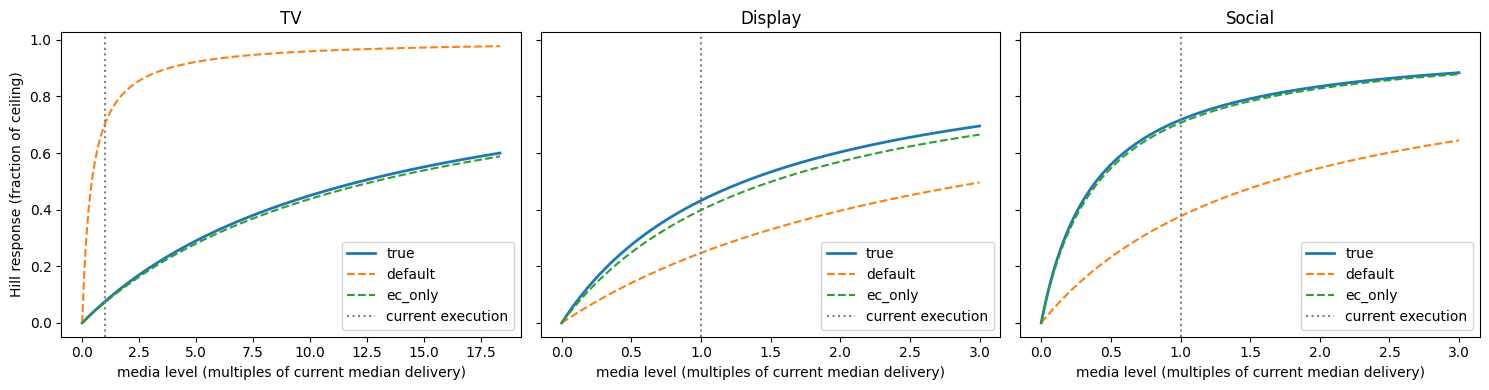

In [9]:
true_slope_m = sim.slope_m.numpy()

fig, axes = plt.subplots(1, len(config.channel_names), figsize=(15, 4), sharey=True)
for i, ch in enumerate(config.channel_names):
  x_max = max(3.0, true_ec_m[i] * 1.5)
  x_grid = np.linspace(0, x_max, 200)

  ax = axes[i]
  ax.plot(
      x_grid,
      hill_value(x_grid, true_ec_m[i], true_slope_m[i])[:, 0],
      label='true',
      linewidth=2,
  )
  for variant in MAIN_VARIANTS:
    posterior_ec = posterior_param_mean(fitted_mmms[variant], 'ec_m')[i]
    posterior_slope = posterior_param_mean(fitted_mmms[variant], 'slope_m')[i]
    ax.plot(
        x_grid,
        hill_value(x_grid, posterior_ec, posterior_slope)[:, 0],
        label=variant,
        linestyle='--',
    )
  ax.axvline(1.0, color='gray', linestyle=':', label='current execution')
  ax.set_title(ch)
  ax.set_xlabel('media level (multiples of current median delivery)')
  if i == 0:
    ax.set_ylabel('Hill response (fraction of ceiling)')
  ax.legend()
plt.tight_layout()
plt.show()

## 4. Marginal response at current execution

A unit-free finite-difference derivative of the Hill curve at `x=1`: how
much incremental (fraction-of-ceiling) response the next bit of delivery
buys, under truth vs. each fitted model. This is the mechanism behind
Section 5's dollar-denominated budget comparison.

In [12]:
def marginal_response(ec, slope, x=1.0, h=1e-3):
  return (hill_value(x + h, ec, slope) - hill_value(x - h, ec, slope)) / (2 * h)


marginal_rows = []
for i, ch in enumerate(config.channel_names):
  row = {'channel': ch, 'true': marginal_response(true_ec_m[i], true_slope_m[i])[0]}
  for variant in MAIN_VARIANTS:
    posterior_ec = posterior_param_mean(fitted_mmms[variant], 'ec_m')[i]
    posterior_slope = posterior_param_mean(fitted_mmms[variant], 'slope_m')[i]
    row[variant] = marginal_response(posterior_ec, posterior_slope)[0]
  marginal_rows.append(row)

pd.DataFrame(marginal_rows).set_index('channel')

,true,default,ec_only
channel,,,
TV,0.069883,0.208765,0.067029
Display,0.245407,0.186071,0.239655
Social,0.202864,0.234812,0.207275


## 5. Budget-reallocation comparison

Does the misdiagnosis in Sections 2-4 actually change a budget decision?
For each fitted model, run Meridian's `BudgetOptimizer` (fixed budget =
current total spend) and compare its recommended TV spend against a
**true-DGP-optimal allocation** computed directly from the simulator's own
known generative parameters (not by forcing Meridian's Bayesian machinery
to fit "the truth"): scale each channel's impressions by a multiplier
(holding CPM fixed, so cost scales linearly with it -- the same
proportionality Meridian's own spend-multiplier tooling uses), re-apply the
true adstock/Hill transform and `beta_gm`, and numerically maximize total
incremental revenue subject to the same fixed total-budget constraint.

In [15]:
def true_incremental_revenue(multipliers_m):
  """Total incremental revenue by channel under a spend multiplier vector.

  Rescales `sim.impression_gtm` by `multipliers_m` (holding CPM fixed), then
  re-runs the exact same population-scaling / adstock / Hill pipeline
  `data_simulator.py` uses to build the ground truth, with the true
  `alpha_m`/`ec_m`/`slope_m`/`beta_gm`.
  """
  scaled_impressions_gtm = sim.impression_gtm.numpy() * np.asarray(
      multipliers_m, dtype=np.float32
  )[np.newaxis, np.newaxis, :]
  scaled_transformed_ipc_gtm = sim.impression_transformer.forward(
      scaled_impressions_gtm
  ).numpy()
  adstock_transformer = adstock_hill.AdstockTransformer(
      alpha=sim.alpha_m, max_lag=8, n_times_output=config.n_times
  )
  hill_transformer = adstock_hill.HillTransformer(ec=sim.ec_m, slope=sim.slope_m)
  media_transformed = hill_transformer.forward(
      adstock_transformer.forward(scaled_transformed_ipc_gtm)
  ).numpy()
  return np.einsum(
      'g,gt,gtm,gm->m',
      sim.p_g.numpy(),
      sim.unit_value.numpy(),
      media_transformed,
      sim.beta_gm.numpy(),
  )


def neg_total_revenue(multipliers_m):
  return -true_incremental_revenue(multipliers_m).sum()


# `sim`'s tensors are float32, so SciPy's default numerical-gradient step
# (~1e-8, tuned for float64) underflows float32 precision and SLSQP sees a
# zero gradient at the start point. A larger, explicit central-difference
# step avoids that.
def neg_total_revenue_grad(multipliers_m, h=1e-3):
  grad = np.zeros(config.n_imp_channels)
  for i in range(config.n_imp_channels):
    m_up, m_down = np.array(multipliers_m, dtype=np.float64), np.array(
        multipliers_m, dtype=np.float64
    )
    m_up[i] += h
    m_down[i] -= h
    grad[i] = -(
        true_incremental_revenue(m_up).sum() - true_incremental_revenue(m_down).sum()
    ) / (2 * h)
  return grad


current_cost_m = sim.cost_gtm.numpy().sum(axis=(0, 1))
total_budget = current_cost_m.sum()

budget_constraint = {
    'type': 'eq',
    'fun': lambda m: np.sum(current_cost_m * m) - total_budget,
    'jac': lambda m: current_cost_m,
}
result = minimize(
    neg_total_revenue,
    x0=np.ones(config.n_imp_channels),
    jac=neg_total_revenue_grad,
    method='SLSQP',
    bounds=[(0.0, None)] * config.n_imp_channels,
    constraints=[budget_constraint],
    options={'maxiter': 200, 'ftol': 1e-10},
)
true_optimal_spend_m = current_cost_m * result.x
result.success, result.message

(True, 'Optimization terminated successfully')

In [16]:
reallocation_df = pd.DataFrame({'channel': config.channel_names})
reallocation_df['current_spend'] = current_cost_m
reallocation_df['true_optimal_spend'] = true_optimal_spend_m

for variant in MAIN_VARIANTS:
  budget_optimizer = optimizer.BudgetOptimizer(meridian=fitted_mmms[variant])
  optimization_results = budget_optimizer.optimize()
  reallocation_df[f'{variant}_optimal_spend'] = (
      optimization_results.optimized_data['spend']
      .sel(channel=config.channel_names)
      .values
  )

reallocation_df.set_index('channel')

,current_spend,true_optimal_spend,default_optimal_spend,ec_only_optimal_spend
channel,,,,
TV,37443324.0,1.145168e+08,48600000.0,48600000.0
Display,15530395.0,7.314535e+06,20200000.0,20200000.0
Social,95423152.0,2.656556e+07,79500000.0,79500000.0


## 6. Robustness: what if the audience/reach assumption isn't exact?

`ec_only`'s prior above was centered on the *exact* ground-truth `ec_m` --
an unfair advantage a real advertiser wouldn't have. `ec_noisy` centers the
same prior on a version of `ec_m` perturbed by independent
`LogNormal(0, 0.25)` noise per channel per seed, emulating a planning
assumption about audience size/reach that's only *approximately* right --
and, since `model_utils.build_reach_based_ec_prior`'s prior `scale` now
grows with `audience_noise_scale` (rather than staying fixed), `ec_noisy`'s
prior is also correspondingly less confident than `ec_only`'s, the same way
a real advertiser's stated uncertainty about their inputs should translate
into how tight a prior they can honestly claim. This reruns the companion
notebook's 20-seed 90% HDI coverage study with all three variants, plus the
ceiling-fraction bias from Section 2, to check whether the reach-informed
prior still outperforms default when it isn't handed the exact answer (or
a falsely overconfident one).

**Note:** as in the companion notebook, MCMC settings here are reduced
from Section 2's to keep ~20 x 3 fits practical -- increase `N_SEEDS` and
the MCMC settings for a more rigorous (and much slower) run.

In [ ]:
N_SEEDS = 20
SEED_NUMS = list(range(2000, 2000 + N_SEEDS))

# Reduced relative to Section 2 -- see markdown note above.
MCMC_KWARGS = dict(n_chains=2, n_adapt=500, n_burnin=200, n_keep=250, seed=1)
HDI_PROB = 0.9
PARAM_PREFIXES = ('ec_m', 'roi_m')


def true_values_for_seed(seed_sim, seed_ground_truth):
  return {
      'ec_m': dict(zip(config.channel_names, seed_sim.ec_m.numpy())),
      'roi_m': dict(zip(config.channel_names, seed_ground_truth['roi_m'])),
  }


def coverage_rows_for_fit(summary_df, prior_label, seed_num, truth):
  rows = []
  hdi_lo_col = f'hdi_{round((1 - HDI_PROB) / 2 * 100)}%'
  hdi_hi_col = f'hdi_{round((1 - (1 - HDI_PROB) / 2) * 100)}%'
  for prefix in PARAM_PREFIXES:
    sub = filter_param_summary(summary_df, prefix)
    for _, row in sub.iterrows():
      channel = row['index'].split('[')[-1].rstrip(']')
      if channel not in truth[prefix]:
        continue
      true_value = truth[prefix][channel]
      rows.append({
          'seed_num': seed_num,
          'prior': prior_label,
          'param': prefix,
          'channel': channel,
          'mean': row['mean'],
          'true_value': true_value,
          'covered': bool(row[hdi_lo_col] <= true_value <= row[hdi_hi_col]),
      })
  return rows

In [ ]:
coverage_rows = []
ceiling_bias_rows = []
seed_variant_failures = []

for seed_num in SEED_NUMS:
  seed_overrides = dict(BASE_CONFIG_OVERRIDES, seed_num=seed_num)
  seed_config = SimulationConfig.from_dict(seed_overrides)
  try:
    seed_sim, seed_data, seed_ground_truth = build_simulated_input(seed_config)
  except Exception as e:  # pylint: disable=broad-except
    seed_variant_failures.append((seed_num, 'ALL', repr(e)))
    print(f'seed {seed_num}: data generation FAILED ({e!r}) -- all variants skipped')
    continue

  truth = true_values_for_seed(seed_sim, seed_ground_truth)
  seed_true_ceiling = ceiling_fraction_at_median(seed_sim.ec_m.numpy())
  # Independent of the TF seeding used for the DGP -- perturbs `ec_noisy`'s
  # assumed audience/reach reproducibly per seed.
  rng = np.random.default_rng(seed_num + 10_000)

  n_ok = 0
  for variant in PRIOR_VARIANTS:
    try:
      seed_model_spec = build_model_spec(variant, seed_sim, seed_config, rng=rng)
      seed_mmm = model.Meridian(input_data=seed_data, model_spec=seed_model_spec)
      seed_mmm.sample_prior(200)
      seed_mmm.sample_posterior(**MCMC_KWARGS)
      seed_summary = az.summary(
          seed_mmm.inference_data, hdi_prob=HDI_PROB
      ).reset_index()
      coverage_rows += coverage_rows_for_fit(seed_summary, variant, seed_num, truth)

      posterior_ec = posterior_param_mean(seed_mmm, 'ec_m')
      posterior_slope = posterior_param_mean(seed_mmm, 'slope_m')
      posterior_ceiling = ceiling_fraction_at_median(posterior_ec, posterior_slope)
      for i, ch in enumerate(seed_config.channel_names):
        ceiling_bias_rows.append({
            'seed_num': seed_num,
            'prior': variant,
            'channel': ch,
            'true_ceiling_frac': seed_true_ceiling[i],
            'posterior_ceiling_frac': posterior_ceiling[i],
            'abs_bias': abs(posterior_ceiling[i] - seed_true_ceiling[i]),
        })
      n_ok += 1
    except Exception as e:  # pylint: disable=broad-except
      seed_variant_failures.append((seed_num, variant, repr(e)))
      print(f'seed {seed_num} [{variant}]: FAILED ({e!r}) -- skipped')

  print(f'seed {seed_num}: done ({n_ok}/{len(PRIOR_VARIANTS)} variants succeeded)')

n_expected = len(SEED_NUMS) * len(PRIOR_VARIANTS)
print(f'\n{n_expected - len(seed_variant_failures)}/{n_expected} seed x variant fits'
      f' completed successfully ({len(seed_variant_failures)} failures -- see'
      ' seed_variant_failures for detail)')
coverage_df = pd.DataFrame(coverage_rows)
ceiling_bias_df = pd.DataFrame(ceiling_bias_rows)

### Results: 90% HDI coverage and ceiling-fraction bias, all three priors

A well-calibrated 90% HDI should contain the true value roughly 90% of the
time. If `ec_noisy` tracks `ec_only` far more closely than `default` does
-- on both coverage and ceiling-fraction bias -- that's evidence the
reach-informed prior doesn't need to be exact to dramatically outperform
assuming the channel is already near saturation.

In [ ]:
coverage_summary = (
    coverage_df.groupby(['param', 'channel', 'prior'])['covered']
    .mean()
    .unstack('prior')
    .reindex(columns=list(PRIOR_VARIANTS))
    .rename(columns=lambda c: f'{c}_coverage')
)
coverage_summary

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = coverage_summary.reset_index()
labels = plot_df['param'] + '[' + plot_df['channel'] + ']'
x = np.arange(len(plot_df))
variant_names = list(PRIOR_VARIANTS)
n_variants = len(variant_names)
width = 0.8 / n_variants

for i, variant in enumerate(variant_names):
  offset = (i - (n_variants - 1) / 2) * width
  ax.bar(x + offset, plot_df[f'{variant}_coverage'], width, label=variant)

ax.axhline(0.9, color='black', linestyle='--', linewidth=1, label='nominal 90%')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('90% HDI coverage rate')
n_completed_seeds = len(SEED_NUMS) - len({s for s, v, _ in seed_variant_failures if v == 'ALL'})
ax.set_title(f'HDI coverage across {n_completed_seeds} seeds: '
             f'{", ".join(variant_names)} priors')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
ceiling_bias_summary = (
    ceiling_bias_df.groupby(['channel', 'prior'])['abs_bias']
    .mean()
    .unstack('prior')
    .reindex(columns=list(PRIOR_VARIANTS))
    .rename(columns=lambda c: f'{c}_mean_abs_bias')
)
ceiling_bias_summary

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_df = ceiling_bias_summary.reset_index()
x = np.arange(len(plot_df))

for i, variant in enumerate(variant_names):
  offset = (i - (n_variants - 1) / 2) * width
  ax.bar(x + offset, plot_df[f'{variant}_mean_abs_bias'], width, label=variant)

ax.set_xticks(x)
ax.set_xticklabels(plot_df['channel'])
ax.set_ylabel('mean |posterior ceiling frac - true ceiling frac|')
ax.set_title(f'Ceiling-fraction bias across {n_completed_seeds} seeds')
ax.legend()
plt.tight_layout()
plt.show()

## Conclusion

Put together, Sections 2-5 tell a concrete story on a single seed: a
large-audience channel that's genuinely under-reached and under-frequency'd
has a true `ec_m` far above its current delivery level (under this
simulation's stated half-of-audience-at-mean-frequency assumption -- see
the caveat at the top of this notebook), so it's still deep in the rising
part of its response curve. Meridian's default `ec_m` prior -- built
around "current execution is already near half-saturation" -- can't tell
that from a channel that's genuinely close to flat, and concludes the
wrong thing: a much higher ceiling-fraction-captured number, a flatter
response curve, a smaller marginal return, and (if Section 5's bars show
it) a `BudgetOptimizer` recommendation that under-invests in the channel
relative to the true optimum. A reach-informed `ec_m` prior, built from
the same audience/reach/frequency planning inputs an advertiser already
has, recovers that ground truth and the corresponding recommendation --
and, per Section 6, does so even when that planning input is only
approximately, not exactly, right. None of this validates 50%-of-audience
as the real-world half-saturation point -- it validates that *whatever*
that point turns out to be, a reach-informed prior tracks it far better
than assuming current execution already sits near it.